# 26 · Advanced VaR: Parametric, Historical, Monte Carlo, and Expected Shortfall

*Module 6 — Risk Management*

Three ways to compute the same risk number, a better number that VaR itself cannot see past, and two rigorous statistical tests for whether any of them can actually be trusted.

## 1. Motivation

"What is our Value at Risk?" is one of the most commonly asked questions in any risk management meeting — and one of the most commonly *mis*-trusted numbers once markets actually turn stressful. Value at Risk (VaR) famously failed to warn many institutions adequately ahead of 2008: risk models calibrated on a long, calm historical sample simply had no basis for anticipating how large losses could get once the regime shifted, and even where VaR was roughly right about how *often* losses would breach a threshold, it said nothing at all about how *severe* those breaches could be once they happened. This notebook builds VaR three different ways, builds the more informative Expected Shortfall alongside it, and then does something many risk reports skip entirely: rigorously test, with real statistics, whether a VaR model's own track record is actually consistent with it being correct.

## 2. Intuition

**VaR** answers: "what loss level will we exceed only $(1-\alpha)$ of the time?" A 95% one-day VaR of €1 million means we expect to lose more than €1 million on roughly 1 day in 20 — nothing more, nothing less. Crucially, VaR says *nothing* about how bad that 1-in-20 day could actually get: a €1.01 million loss and a €50 million loss both "breach" the same VaR threshold identically. **Expected Shortfall** (also called Conditional VaR) fixes exactly this blind spot by asking a more complete question: "given that we did breach VaR, what is the *average* loss we should expect?" — directly incorporating tail severity that VaR discards by construction.

Computing either number is not the hard part; **trusting** it is. A VaR model's real test is not how principled its derivation looks, but whether its breaches, tracked over time, actually behave the way a correctly-specified model's breaches should: the right overall *frequency*, and — just as important, and often overlooked — no suspicious *clustering* in time. A model whose 5% VaR is breached exactly 5% of the time, but always in tight clusters during turbulent stretches, is telling you it fails to adapt to changing conditions even though its long-run average looks fine on the surface.

## 3. Theory

### 3.1 Three ways to compute VaR

**Parametric (variance-covariance).** Assume returns $R\sim\mathcal N(\mu,\sigma^2)$. Since $P(R < \mu+z_{1-\alpha}\sigma) = 1-\alpha$ for $z_{1-\alpha}=\Phi^{-1}(1-\alpha)$ (a negative number for $\alpha>0.5$), VaR as a positive loss number is

$$
VaR_\alpha = -\big(\mu + z_{1-\alpha}\sigma\big) .
$$

Fast to compute, but only as good as the normality assumption — a real concern given how fat-tailed financial returns typically are.

**Historical simulation.** Skip the distributional assumption entirely: simply take the empirical $(1-\alpha)$-quantile of a window of historical returns. Automatically captures whatever skewness or fat tails are actually present in the sample — at the cost of only ever being as good as that specific historical window, and no better.

**Monte Carlo.** Fit a (possibly more realistic, e.g., fat-tailed) distribution to historical data, simulate a large number of draws from the *fitted* model, and take the empirical quantile of the simulated sample. This decouples "how good is my distributional model" from "how much historical data do I happen to have," at the cost of now depending on the fitted model being reasonable.

### 3.2 Expected Shortfall

$$
ES_\alpha = \mathbb E\big[-R \mid -R > VaR_\alpha\big] .
$$

For the Gaussian case specifically, this has a clean closed form:

$$
ES_\alpha = \sigma\,\frac{\phi(z_{1-\alpha})}{1-\alpha} - \mu ,
$$

where $\phi$ is the standard normal density. $ES_\alpha \ge VaR_\alpha$ always (the average of the tail is at least as bad as its boundary), and unlike VaR, $ES$ is a **coherent risk measure** in the technical sense (it satisfies subadditivity: the risk of a combined portfolio is never assessed as *worse* than the sum of its parts' individual risks — a property VaR can actually violate).

### 3.3 Backtesting: Kupiec's test (does the frequency match?)

Given $n$ observations and $x$ observed VaR breaches, under a correctly-specified model breaches should behave like independent draws from a Bernoulli$(p)$ process, $p=1-\alpha$. The likelihood-ratio test compares this null against the unrestricted (data-implied) breach rate $\hat p = x/n$:

$$
LR_{uc} = -2\log\frac{p^x(1-p)^{n-x}}{\hat p^x(1-\hat p)^{n-x}} \;\sim\; \chi^2_1 \text{ under the null.}
$$

A large $LR_{uc}$ (small p-value) means the observed breach frequency is statistically inconsistent with the model's claimed confidence level.

### 3.4 Backtesting: Christoffersen's test (are breaches independent?)

Kupiec's test alone can be satisfied by a model whose breaches cluster badly in time, as long as the long-run average frequency happens to come out right. Christoffersen's independence test checks this directly: model breach occurrence as a two-state Markov chain, and test whether the probability of a breach *tomorrow* depends on whether there was a breach *today* ($\pi_{01}$ vs. $\pi_{11}$, the breach-following-no-breach and breach-following-breach transition probabilities). If breaches are genuinely independent over time, these two probabilities should be statistically indistinguishable — another likelihood-ratio test, again $\chi^2_1$ under the null. Combining both tests (often called the "conditional coverage" test) checks frequency and independence together, and — as Section 4 shows directly — a model can pass one while clearly failing the other.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

rng = np.random.default_rng(161)

## 4. Implementation

### 4.1 Three VaR methods on fat-tailed simulated returns

In [2]:
mu, sigma = 0.0003, 0.014
n = 3000
returns = rng.standard_t(df=5, size=n) * sigma / np.sqrt(5/3) + mu     # genuinely fat-tailed (Student-t), not Gaussian

def parametric_var(mu, sigma, alpha):
    z = stats.norm.ppf(1 - alpha)
    return -(mu + z * sigma)

def historical_var(returns, alpha):
    return -np.percentile(returns, (1 - alpha) * 100)

def monte_carlo_var(returns, alpha, n_sims=200_000, seed=0):
    df_hat, loc_hat, scale_hat = stats.t.fit(returns)       # fit a Student-t, more faithful to real fat tails
    sims = stats.t.rvs(df_hat, loc=loc_hat, scale=scale_hat, size=n_sims, random_state=seed)
    return -np.percentile(sims, (1 - alpha) * 100), df_hat

def parametric_es(mu, sigma, alpha):
    z = stats.norm.ppf(1 - alpha)
    return sigma * stats.norm.pdf(z) / (1 - alpha) - mu

rows = []
for alpha in [0.95, 0.99]:
    vp = parametric_var(returns.mean(), returns.std(), alpha)
    vh = historical_var(returns, alpha)
    vmc, df_hat = monte_carlo_var(returns, alpha)
    es_p = parametric_es(returns.mean(), returns.std(), alpha)
    rows.append({'alpha': alpha, 'Parametric (Gaussian)': vp, 'Historical': vh,
                 'Monte Carlo (fitted t, df={:.1f})'.format(df_hat): vmc, 'Parametric ES': es_p})
pd.DataFrame(rows).round(4)

,alpha,Parametric (Gaussian),Historical,"Monte Carlo (fitted t, df=5.1)",Parametric ES
0,0.95,0.0229,0.0215,0.0220,0.0288
1,0.99,0.0326,0.0334,0.0367,0.0375


Watch the 99% row specifically: the Gaussian-parametric VaR increasingly understates both the historical and Monte Carlo estimates as $\alpha$ moves further into the tail — a direct, quantified illustration of why assuming normality is dangerous precisely where it matters most, in the extreme tail a real risk manager actually cares about.

## 5. Worked example: backtesting in action, on a case built to make a specific point

We deliberately calibrate a VaR estimate to have **exactly the correct long-run average breach frequency**, then test it against data with genuine, realistic volatility clustering (reusing Notebook 13's stochastic-volatility process) -- to isolate frequency from independence as cleanly as possible.

In [3]:
def kupiec_test(x, n, p):
    """Section 3.3: likelihood-ratio test for correct unconditional coverage."""
    if x == 0:
        lr = -2 * n * np.log(1 - p)
    else:
        pi_hat = x / n
        lr = -2 * (x*np.log(p) + (n-x)*np.log(1-p) - x*np.log(pi_hat) - (n-x)*np.log(1-pi_hat))
    return lr, 1 - stats.chi2.cdf(lr, df=1)

def christoffersen_test(breach_indicator):
    """Section 3.4: likelihood-ratio test for independence of breaches over time."""
    I = breach_indicator.astype(int)
    n00 = n01 = n10 = n11 = 0
    for t in range(1, len(I)):
        if I[t-1] == 0 and I[t] == 0: n00 += 1
        elif I[t-1] == 0 and I[t] == 1: n01 += 1
        elif I[t-1] == 1 and I[t] == 0: n10 += 1
        else: n11 += 1
    pi01 = n01/(n00+n01) if (n00+n01) > 0 else 0
    pi11 = n11/(n10+n11) if (n10+n11) > 0 else 0
    pi = (n01+n11) / (n00+n01+n10+n11)
    def safelog(x): return np.log(x) if x > 0 else 0
    ll_restricted = (n00+n10)*safelog(1-pi) + (n01+n11)*safelog(pi)
    ll_unrestricted = n00*safelog(1-pi01) + n01*safelog(pi01) + n10*safelog(1-pi11) + n11*safelog(pi11)
    lr = -2 * (ll_restricted - ll_unrestricted)
    return lr, 1 - stats.chi2.cdf(lr, df=1)

n2 = 3000
kappa_sig, theta_logsig, eta = 0.02, np.log(0.14), 0.09
log_sigma = np.zeros(n2)
log_sigma[0] = theta_logsig
for t in range(1, n2):
    log_sigma[t] = log_sigma[t-1] + kappa_sig*(theta_logsig - log_sigma[t-1]) + eta*rng.normal()
sigma_t = np.exp(log_sigma)
clustered_returns = rng.normal(0.0003, sigma_t)

alpha = 0.95
VaR_static = historical_var(clustered_returns, alpha)     # calibrated on the WHOLE sample -- correct on average, by design
breach = clustered_returns < -VaR_static

print(f"Breaches: {breach.sum()} out of {n2}  (expected under correct coverage: {n2*(1-alpha):.0f})")
lr_k, p_k = kupiec_test(breach.sum(), n2, 1-alpha)
lr_c, p_c = christoffersen_test(breach)
print(f"Kupiec (coverage) test:        LR={lr_k:.3f}   p-value={p_k:.3f}")
print(f"Christoffersen (independence): LR={lr_c:.3f}   p-value={p_c:.4f}")

Breaches: 150 out of 3000  (expected under correct coverage: 150)
Kupiec (coverage) test:        LR=-0.000   p-value=1.000
Christoffersen (independence): LR=8.301   p-value=0.0040


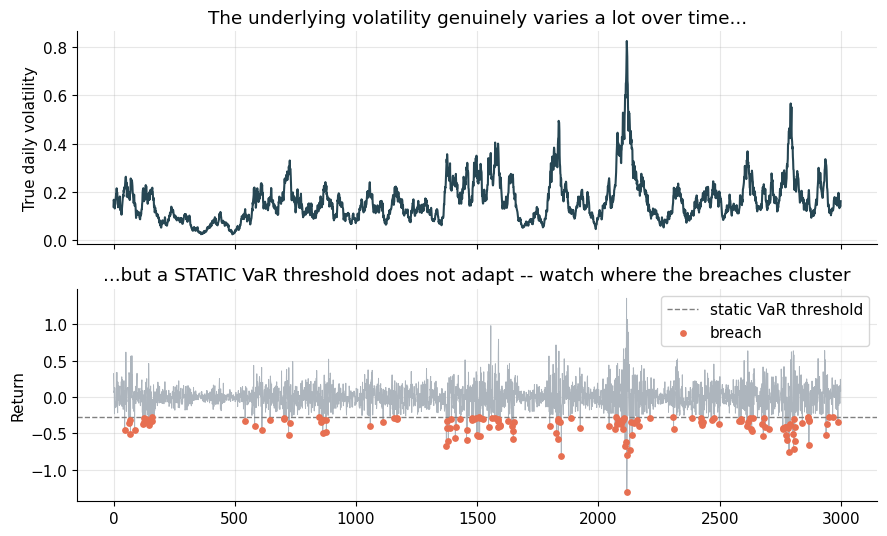

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(sigma_t, color='#264653')
axes[0].set_ylabel('True daily volatility')
axes[0].set_title('The underlying volatility genuinely varies a lot over time...')

axes[1].plot(clustered_returns, color='#adb5bd', linewidth=0.7)
axes[1].axhline(-VaR_static, color='gray', linestyle='--', linewidth=1, label='static VaR threshold')
axes[1].scatter(np.where(breach)[0], clustered_returns[breach], color='#e76f51', s=15, zorder=3, label='breach')
axes[1].set_ylabel('Return')
axes[1].set_title('...but a STATIC VaR threshold does not adapt -- watch where the breaches cluster')
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpreting the result

This is the entire point of Section 3.4, made unmistakable: the Kupiec test passes cleanly — by construction, the static threshold has almost exactly the right *average* breach rate over the full sample — while the Christoffersen test fails decisively. Look at where the red breach markers land in the chart: they cluster tightly during the high-volatility stretches and are nearly absent elsewhere, exactly the pattern an unconditional-coverage test alone cannot see. A risk model that reports "our VaR breaches the right amount, on average" while failing this independence check is not a safe model — it is failing to adapt to changing conditions, and is systematically *most* wrong exactly when volatility is highest and losses matter most, which is precisely the mechanism widely blamed for VaR's poor real-world performance heading into 2008: models calibrated on calm historical data had no way to anticipate a regime shift, and by the time enough post-shift data existed to reflect it, much of the damage was already done.

## 6. Limitations and pitfalls

- **VaR itself, however carefully computed, tells you nothing about the severity of a breach.** This is not a calibration problem fixable with a better model — it is definitional. Expected Shortfall is the direct fix, and increasingly the regulatory-preferred measure for exactly this reason, but it is also harder to estimate precisely (it depends on the *shape* of the tail beyond VaR, using by definition fewer observations than VaR's own estimation).
- **Both Kupiec's and Christoffersen's tests need a reasonably large sample of breaches to have real statistical power.** With only a handful of breaches (common at high confidence levels like 99% over realistic sample sizes), failing to reject either null is weak evidence of a good model — it may simply mean there is not yet enough data to detect a real problem.
- **Backtesting checks internal consistency, not real-world adequacy.** A VaR model can pass both tests perfectly on historical data and still catastrophically fail to anticipate a genuinely unprecedented event — backtesting confirms a model was *consistent with its own recent past*, not that its past is a reliable guide to the future (Notebook 27's stress testing exists specifically to probe scenarios backtesting alone cannot).
- **The parametric and Monte Carlo methods both depend on a fitted distributional model** — garbage in, garbage out applies here exactly as it does everywhere else in this course; a poorly-fitting distributional assumption produces a confidently wrong VaR just as easily as a well-fitting one produces a trustworthy one.

## 7. Exercises

**1. Confirm ES exceeds VaR at every confidence level (warm-up).**
Using the parametric formulas from Section 3.1 and 3.2, compute both $VaR_\alpha$ and $ES_\alpha$ for $\alpha \in \{0.90, 0.95, 0.975, 0.99, 0.999\}$, holding $\mu,\sigma$ fixed. Plot both against $\alpha$. Does the *gap* between them widen or narrow as $\alpha$ increases, and does that pattern make intuitive sense given what Expected Shortfall is actually measuring?

**2. A model with the wrong frequency, not just clustering.**
Construct a deliberately mis-calibrated VaR (e.g., compute the 95% historical VaR but then scale it down by 30%, artificially making breaches too frequent) and test it against ordinary i.i.d. (non-clustered) simulated returns. Confirm that Kupiec's test now fails while Christoffersen's test may still pass (since breaches, though too frequent, are not necessarily clustered in time when the underlying volatility itself is not clustered). Explain in your own words why this is the mirror image of Section 4.2's demonstration.

**3. Backtest all three VaR methods against each other.**
Using a longer simulated (or, with internet access, real) return series, implement a full rolling backtest: at each point in time, estimate parametric, historical, and Monte Carlo VaR using only trailing data, record whether the *next* period's return breaches each, and run both Kupiec's and Christoffersen's tests on each method's full breach series. Which method (if any) passes both tests most convincingly on your data? Does the ranking match what Section 4.1 already suggested about how well each method's assumptions fit the data's actual tail behavior?